In [1]:
import VMBQC_functions
from VMBQC_functions import *

In [2]:
torch.cuda.is_available()

True

In [3]:
# Hyperparameters

# Pennylane devices have inbuild command names "shots" which is number of samples for a specific circuit architecture
N=10 # number of "shots"

samples=8000 # Total number of samples from MBQC-CQCA (includes the "shots" for each circuit with different byproducts)
target_samples = samples
runs=int(samples/N) # Number of times our model should run (at each of this "runs", the specific pennylane circuit provides N=10 "shots" / samples)

qubits=7
depth=4
layers=depth

## GIF plotting

In [4]:
k=[2, 4]
c_t_1 = np.loadtxt(f'learned_models/{k}_k_target_unit_learningmodel_depth:{depth}_loss_{9}.txt')
c_t_1.min()

tensor(0.00092564, requires_grad=True)

In [5]:
k=[2+qubits,4+qubits]
c_t_2 = np.loadtxt(f'learned_models/{k}_k_target_unit_learningmodel_depth:{depth}_loss_{9}.txt')
c_t_2.min()

tensor(0.00039693, requires_grad=True)

In [6]:
k=[2+qubits*2,4+qubits*2]
c_t_3 = np.loadtxt(f'learned_models/{k}_k_target_unit_learningmodel_depth:{depth}_loss_{9}.txt')
c_t_3.min()

tensor(0.00037039, requires_grad=True)

In [48]:
# idx = 3 # The qubits in each layer we want to train
# k=np.arange(idx, idx + qubits * depth, qubits)
# c_t = np.loadtxt(f'channel_diff_layer_p/{qubits}_qubit_pt_target_{k}:k_emodel_depth:{depth}_loss_{9}.txt')
# # c_t = np.concatenate([c_t_1,c_t_2])
# c_t.min()

In [8]:
# c_t_1 = np.loadtxt(f'single_param/channel_models/qubit:{qubits}_depth:{depth}_all_same_p_loss_{7}.txt')
# c_t_2 = np.loadtxt(f'single_param/channel_models/qubit:{qubits}_depth:{depth}_all_same_p_loss_{9}.txt')
# c_t_1 = np.loadtxt(f'single_param/channel_models/qubit:{qubits}_depth:{depth}_all_diff_p_loss_{3}.txt')
# c_t_2 = np.loadtxt(f'single_param/channel_models/qubit:{qubits}_depth:{depth}_all_diff_p_loss_{9}.txt')
# c_t_1 = np.loadtxt(f'single_param/channel_models/qubit:{qubits}_depth:{depth}_1p_1l_loss_{0}.txt')
# c_t_2 = np.loadtxt(f'single_param/channel_models/qubit:{qubits}_depth:{depth}_1p_1l_loss_{9}.txt')
# c_t_1 = np.loadtxt(f'single_param/channel_models/qubit:{qubits}_depth:{depth}_1p_1l_notallq_loss_{3}.txt')
# c_t_2 = np.loadtxt(f'single_param/channel_models/qubit:{qubits}_depth:{depth}_1p_1l_notallq_loss_{9}.txt')
# c_t = np.loadtxt(f'single_param/channel_models/qubit:{qubits}_depth:{depth}_1p_diffq_loss_{9}.txt')
# c_t = np.loadtxt(f'diff_target_analysis/layerwise_target/{qubits}_qubit_pt_target_emodel_all_same_p_depth:{depth}_loss_{9}.txt')

# c_t = np.concatenate([c_t_1,c_t_2])

# c_t.min()

In [42]:
# p_t=np.loadtxt(f'new_models/layerwise_learning/{qubits}_qubit_pt_target_{k}:k_emodel_learningmodel_depth:{depth}_par_{9}.txt')
# p_t=np.loadtxt(f'channel_diff_layer_p/{qubits}_qubit_pt_target_{k}:k_emodel_depth:{depth}_par_{9}.txt')
# gen_prob_par(sigmoid(p_t[torch.argmin(torch.tensor(c_t))][:qubits*depth]),qubits,depth,f'Optimal $p_c$={np.round(sigmoid(p_t[torch.argmin(torch.tensor(c_t))][3]),3)}')
# gen_prob_par(sigmoid(p_t[torch.argmin(torch.tensor(c_t))][:qubits*depth]),qubits,depth,f'Optimal $p_c$')

In [9]:
# # p_t_1=np.loadtxt(f'single_param/channel_models/qubit:{qubits}_depth:{depth}_1p_1l_notallq_par_{3}.txt')
# # p_t_2=np.loadtxt(f'single_param/channel_models/qubit:{qubits}_depth:{depth}_1p_1l_notallq_par_{9}.txt')
# p_t_1=np.loadtxt(f'new_models/layerwise_learning/{qubits}_qubit_pt_target_{k}:k_emodel_learningmodel_depth:{depth}_par_{4}.txt')
# p_t_2=np.loadtxt(f'new_models/layerwise_learning/{qubits}_qubit_pt_target_{k}:k_emodel_learningmodel_depth:{depth}_par_{9}.txt')
# p_t=np.loadtxt(f'single_param/channel_models/qubit:{qubits}_depth:{depth}_1p_diffq_par_{9}.txt')
# p_t=np.loadtxt(f'diff_target_analysis/layerwise_target/{qubits}_qubit_pt_target_emodel_all_same_p_depth:{depth}_par_{9}.txt')
# p_p_t=np.loadtxt(f'diff_target_analysis/layerwise_target/{qubits}_qubit_pt_target_emodel_depth:{depth}_layer_p_k:{k}_par_{9}.txt')
# p_t = np.concatenate([p_t_1,p_t_2])
# gen_prob_par(sigmoid(p_t[torch.argmin(torch.tensor(c_t))][:qubits*depth]),qubits,depth,f'Optimal $p_c$={np.round(sigmoid(p_t[torch.argmin(torch.tensor(c_t))][3]),3)}')
# gen_prob_par(sigmoid(p_p_t[torch.argmin(torch.tensor(c_t))][:qubits*depth]),qubits,depth,f'Optimal $p_c$')

In [7]:
# np.savetxt(f'new_models/qubitwise_target/{qubits}_qubit_pt_target_unit_learningmodel_depth:{depth}_loss_{r}.txt', cost_arr)
# np.savetxt(f'new_models/qubitwise_target/{qubits}_qubit_pt_target_unit_learningmodel_depth:{depth}_par_{r}.txt', params_arr)

u_t_1=np.loadtxt(f'learned_models/unit_target_unit_learningmodel_depth:{depth}_loss_{7}.txt')
u_t_2=np.loadtxt(f'learned_models/unit_target_unit_learningmodel_depth:{depth}_loss_{9}.txt')
u_t=np.concatenate([u_t_1,u_t_2])
u_t.shape

(2000,)

In [13]:
ave_cost_1=[]
std_1=[]
a_1=[]
total_cost_arr_1=[]


runs_2=10
iterations=199
for r in range(runs_2):
    total_cost_arr_1.append(u_t[r*(iterations+1):(r+1)*(iterations+1)])
    
for j in range((iterations+1)):
    a_1=[]
    for i in range(runs_2):
        a_1.append(total_cost_arr_1[i][j])
    std_1.append(np.std(a_1))
    ave_cost_1.append(np.average(a_1))



ave_cost_1p=[]
std_1p=[]
a_1p=[]
total_cost_arr_1p=[]


runs_2=10
iterations=199
for r in range(runs_2):
    total_cost_arr_1p.append(c_t_1[r*(iterations+1):(r+1)*(iterations+1)])
    
for j in range((iterations+1)):
    a_1p=[]
    for i in range(runs_2):
        a_1p.append(total_cost_arr_1p[i][j])
    std_1p.append(np.std(a_1p))
    ave_cost_1p.append(np.average(a_1p))


ave_cost_2p=[]
std_2p=[]
a_2p=[]
total_cost_arr_2p=[]


runs_2=10
iterations=199
for r in range(runs_2):
    total_cost_arr_2p.append(c_t_2[r*(iterations+1):(r+1)*(iterations+1)])
    
for j in range((iterations+1)):
    a_2p=[]
    for i in range(runs_2):
        a_2p.append(total_cost_arr_2p[i][j])
    std_2p.append(np.std(a_2p))
    ave_cost_2p.append(np.average(a_2p))



ave_cost_3p=[]
std_3p=[]
a_3p=[]
total_cost_arr_3p=[]


runs_2=10
iterations=199
for r in range(runs_2):
    total_cost_arr_3p.append(c_t_3[r*(iterations+1):(r+1)*(iterations+1)])
    
for j in range((iterations+1)):
    a_3p=[]
    for i in range(runs_2):
        a_3p.append(total_cost_arr_3p[i][j])
    std_3p.append(np.std(a_3p))
    ave_cost_3p.append(np.average(a_3p))


/tmp/ipykernel_3975726/1591148503.py:23: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  ax.semilogy(x, y_1p, 'k', color='#F5C095',label='$\mathcal{E}_{c}(q=3)$')
/tmp/ipykernel_3975726/1591148503.py:27: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  ax.semilogy(x, y_2p, 'k', color='navy',label='$\mathcal{E}_{c}(q=3)$')


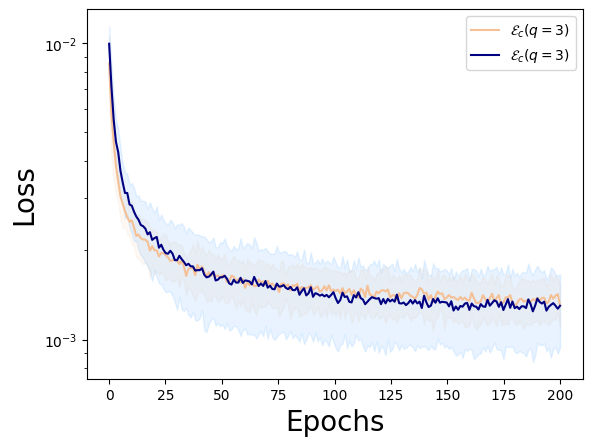

In [23]:
fig, ax = plt.subplots()
x=np.linspace(0,iterations+1,iterations+1)
# y=ave_cost
# yerr=std

y_1=ave_cost_1
yerr_1=std_1

y_1p=ave_cost_1p
yerr_1p=std_1p

y_2p=ave_cost_2p
yerr_2p=std_2p

y_3p=ave_cost_3p
yerr_3p=std_3p

# ax.semilogy(x, y, 'k', color='navy',label='$\mathcal{E}_{c}$')
# ax.fill_between(x, np.array(y)+np.array(yerr)/2,np.array(y)+(-1)*np.array(yerr)/2,
#     alpha=0.1, edgecolor='dodgerblue', facecolor='dodgerblue')

# ax.semilogy(x, y_1, 'k', color='#6CDB7A',label='$U_c$')
# ax.fill_between(x, np.array(y_1)+np.array(yerr_1),np.array(y_1)+(-1)*np.array(yerr_1),
#     alpha=0.1, edgecolor='#7FFF00', facecolor='#7FFF00')

ax.semilogy(x, y_1p, 'k', color='#F5C095',label='$\mathcal{E}_{c}(q=3)$')
ax.fill_between(x, np.array(y_1p)+np.array(yerr_1p),np.array(y_1p)+(-1)*np.array(yerr_1p),
    alpha=0.1, edgecolor='#F5C095', facecolor='#F5C095')

ax.semilogy(x, y_2p, 'k', color='navy',label='$\mathcal{E}_{c}(q=3)$')
ax.fill_between(x, np.array(y_2p)+np.array(yerr_2p),np.array(y_2p)+(-1)*np.array(yerr_2p),
    alpha=0.1, edgecolor='dodgerblue', facecolor='dodgerblue')

# plt.title(r'Target distribution: $\widetilde{\epsilon}_{c}(p=\sim0.7)$')
# plt.ylim(0.00000007,0.1)
plt.xlabel('Epochs',fontsize=20)
plt.ylabel('Loss',fontsize=20)
plt.legend()
plt.show()

In [8]:
total_cost_arr_1=[]


runs_2=10
iterations=199
for r in range(runs_2):
    total_cost_arr_1.append(min(u_t[r*(iterations+1):(r+1)*(iterations+1)]))



mean_min_u = np.mean(total_cost_arr_1)
std_u = np.std(total_cost_arr_1)
std_u

9.744618060197103e-05

In [9]:
total_cost_arr_1

[tensor(0.00013843, requires_grad=True),
 tensor(0.0004372, requires_grad=True),
 tensor(0.00012884, requires_grad=True),
 tensor(0.00013112, requires_grad=True),
 tensor(0.00018054, requires_grad=True),
 tensor(0.00012853, requires_grad=True),
 tensor(0.00017148, requires_grad=True),
 tensor(0.00015264, requires_grad=True),
 tensor(0.00016162, requires_grad=True),
 tensor(0.00032365, requires_grad=True)]

In [10]:
total_cost_arr_2=[]


runs_2=10
iterations=199
for r in range(runs_2):
    total_cost_arr_2.append(min(c_t_1[r*(iterations+1):(r+1)*(iterations+1)]))



mean_min_c1 = np.mean(total_cost_arr_2)
std_c1 = np.std(total_cost_arr_2)
std_c1

0.0001889342137411327

In [11]:
total_cost_arr_3=[]


runs_2=10
iterations=199
for r in range(runs_2):
    total_cost_arr_3.append(min(c_t_2[r*(iterations+1):(r+1)*(iterations+1)]))



mean_min_c2 = np.mean(total_cost_arr_3)
std_c2 = np.std(total_cost_arr_3)
std_c2

0.0003491290995457513

In [12]:
total_cost_arr_4=[]


runs_2=10
iterations=199
for r in range(runs_2):
    total_cost_arr_4.append(min(c_t_3[r*(iterations+1):(r+1)*(iterations+1)]))



mean_min_c3 = np.mean(total_cost_arr_4)
std_c3 = np.std(total_cost_arr_4)
std_c3

0.00046282981557093684

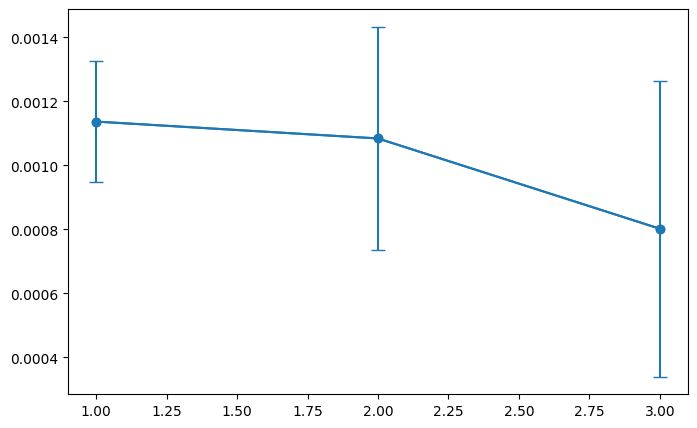

<Figure size 640x480 with 0 Axes>

In [13]:
# Convert to numpy for convenience
y   = np.array([mean_min_c1,mean_min_c2,mean_min_c3])
x   = np.array([1,2,3])
std = np.array([std_c1,std_c2,std_c3])




# Create figure & axis
fig, ax = plt.subplots(figsize=(8,5))

# Plot the mean line
ax.plot(x, y, marker='o', color='tab:blue', label='MIG(q) with TC')



plt.errorbar(x, y, yerr=std, fmt='-o', capsize=5, ecolor='tab:blue', color='tab:blue')
plt.show()


# Remove grid lines
ax.grid(False)

# Labels & title
ax.set_xlabel('$\delta_{TC}$(log scale)', fontsize=16)
ax.set_ylabel('MIG', fontsize=16)
ax.set_title('True factors: $[m,q]$', fontsize=14)

# Legend
ax.legend(fontsize=10)

# Tick formatting
ax.tick_params(which='both', top=True, right=True, labelsize=10)

plt.tight_layout()
plt.show()


In [14]:
total_cost_arr_4

[tensor(0.00056315, requires_grad=True),
 tensor(0.00109845, requires_grad=True),
 tensor(0.00041564, requires_grad=True),
 tensor(0.0003955, requires_grad=True),
 tensor(0.00046476, requires_grad=True),
 tensor(0.00053893, requires_grad=True),
 tensor(0.00037039, requires_grad=True),
 tensor(0.00123534, requires_grad=True),
 tensor(0.00181229, requires_grad=True),
 tensor(0.00112602, requires_grad=True)]

Text(0, 0.5, 'Minimum MMD loss')

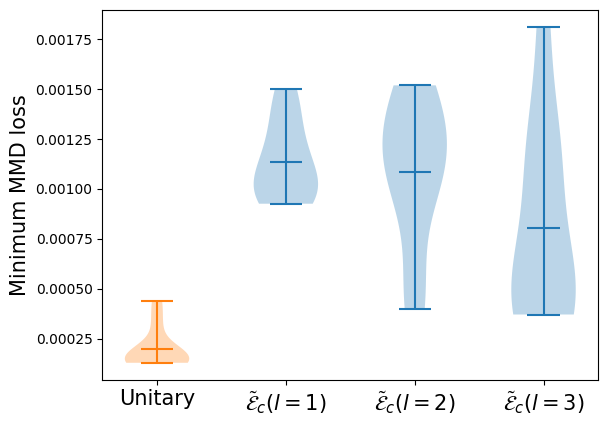

In [15]:
positions = np.arange(3)
vp = plt.violinplot([total_cost_arr_2, total_cost_arr_3, total_cost_arr_4], positions=positions, showmeans=True)

positions = np.arange(1) - 1
vp = plt.violinplot([total_cost_arr_1], positions=positions, showmeans=True)

plt.xticks(np.arange(4)-1 , ['Unitary', r'${\mathcal{\tilde{E}}}_c(l=1)$', r'${\mathcal{\tilde{E}}}_c(l=2)$', r'${\mathcal{\tilde{E}}}_c(l=3)$'],fontsize=15)
plt.ylabel('Minimum MMD loss',fontsize=15)


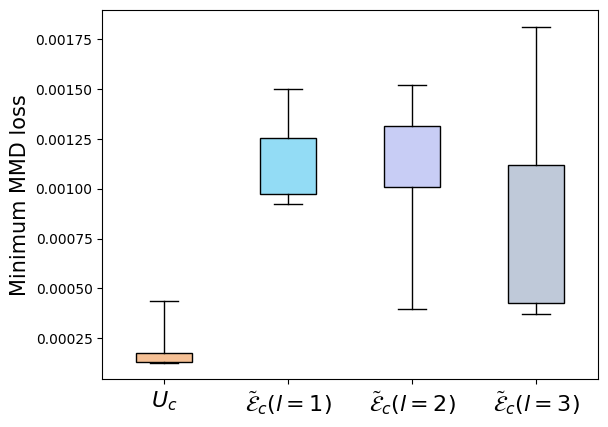

In [16]:


positions = np.arange(3)

colors = ["#F5C095", "#93DCF5", "#C8CDF5", "#BFC9D9"]

labels = ['$U_c$', r'${\mathcal{\tilde{E}}}_c(l=1)$', r'${\mathcal{\tilde{E}}}_c(l=2)$', r'${\mathcal{\tilde{E}}}_c(l=3)$']

x_arr = [total_cost_arr_1,total_cost_arr_2, total_cost_arr_3, total_cost_arr_4]

fig, ax = plt.subplots()
ax.set_ylabel('Minimum MMD loss',fontsize=15)

bplot = ax.boxplot(x_arr,
                   patch_artist=True,  # fill with color
                   tick_labels=labels, whis=6,
                  medianprops=dict(linewidth=0))  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
plt.xticks(fontsize=16)

plt.show()